# Large-Graph Block-Diagonal Training

This notebook is a **scale** tutorial: train a networked GraphKoopman model with
`koopman_sparsity="block_diagonal"` and `NeighborWindowSampler` on a graph large
enough that a dense $N\cdot d$ effective operator is painful. You will measure
memory/runtime against a dense inverse path on a mid-size probe, see the
approximate Jacobi inverse caveat for backward consistency, and evaluate
full-graph forecasts after neighbor-sampled training.

**Prerequisites.** Encode → Koopman step → decode from
[`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb); windowed training ideas
from [`10_advanced_training.ipynb`](10_advanced_training.ipynb). Interactive runs
need the PEMS07 teaching cache (raw NPZ not bundled):

```bash
python scripts/download_pems.py --benchmark 07 \
  --npz-path /path/to/PEMS07.npz --adj-csv /path/to/PEMS07.csv \
  --expected-sha256 <hex>
```


## Setup


In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import os
import random
import time
import tracemalloc
from pathlib import Path

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST") or os.environ.get("CI"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch_geometric.data import Data

from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel
from koopman_graph.data import (
    GraphSnapshotSequence,
    NeighborWindowSampler,
    temporal_split,
)
from koopman_graph.datasets.pems import (
    PemsTrafficBenchmark,
    default_variant_cache_dir,
)
from koopman_graph.datasets.topology import path_edge_index
from koopman_graph.metrics import rmse as kg_rmse
from koopman_graph.operators import GraphKoopmanOperator
from koopman_graph.training import constant_loss_weights

IS_TEST = bool(
    os.environ.get("PYTEST_CURRENT_TEST")
    or os.environ.get("CI")
    or os.environ.get("IS_TEST")
)
SEED = 29
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

LATENT = 4 if IS_TEST else 8
HIDDEN = 8 if IS_TEST else 32
NUM_LAYERS = 1
EPOCHS = 2 if IS_TEST else 20
HORIZONS = (1, 2) if IS_TEST else (3, 6, 12)
PROBE_N = 64 if IS_TEST else 128
SAMPLER_SEEDS = 16 if IS_TEST else 48
WINDOWS_PER_EPOCH = 4 if IS_TEST else 16
BATCH_SIZE = 2 if IS_TEST else 4
LR = 1e-2 if IS_TEST else 1e-3
LOSS_WEIGHTS = constant_loss_weights(reconstruction=1.0, forward=0.5)
print(
    f"IS_TEST={IS_TEST}  EPOCHS={EPOCHS}  PROBE_N={PROBE_N}  "
    f"SAMPLER_SEEDS={SAMPLER_SEEDS}"
)


IS_TEST=False  EPOCHS=20  PROBE_N=128  SAMPLER_SEEDS=48


## Motivation and background

A dense graph Koopman operator materializes (or factors) maps on
$\mathbb{R}^{N\cdot d}$. At PEMS07 scale ($N=883$) or a synthetic path with
$N=2000$, that budget grows as $(Nd)^2$. Two complementary tools keep
training tractable:

1. **`koopman_sparsity="block_diagonal"`** — forward advance stays a sparse
   matvec; `inverse_advance` uses a **Jacobi / blockwise** approximate inverse
   (exact only when neighbor coupling is negligible). See architecture docs and
   Mukherjee et al. 2022 (`Mukherjee2022`) on sparse networked Koopman ideas;
   Azarbahram et al. (arXiv:2509.20071) motivate distributed / consensus-style
   extensions (out of scope for this notebook).
2. **`NeighborWindowSampler`** — each batch is a k-hop induced subgraph with
   remapped indices, so losses never see the full $N$ at once. Predict /
   evaluate remain full-graph.

**Backward consistency** (Azencot et al., 2020) calls `inverse_advance`. With
`block_diagonal`, that inverse is approximate — this notebook keeps
`backward=0` for the main train and shows the approximation error separately.


## Helpers: synthetic path graph, timing, persistence


In [2]:
def make_path_sequence(
    *,
    num_nodes: int,
    num_timesteps: int,
    in_channels: int = 1,
    seed: int = SEED,
) -> GraphSnapshotSequence:
    generator = torch.Generator().manual_seed(seed)
    edge_index = path_edge_index(num_nodes)
    features = torch.randn(
        num_timesteps, num_nodes, in_channels, generator=generator
    )
    for time in range(1, num_timesteps):
        features[time] = 0.9 * features[time - 1] + 0.1 * features[time]
    return GraphSnapshotSequence.from_arrays(features, edge_index)


def dense_effective_bytes(num_nodes: int, latent_dim: int) -> int:
    nd = num_nodes * latent_dim
    return nd * nd * 4  # float32


def rss_mb() -> float:
    # Prefer process RSS (platform units differ); fall back to tracemalloc.
    try:
        import resource
        import sys

        usage = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
        # Darwin: bytes. Linux: kilobytes.
        if sys.platform == "darwin":
            return usage / (1024**2)
        return usage / 1024.0
    except Exception:
        current, _peak = tracemalloc.get_traced_memory()
        return current / (1024**2)


def time_inverse_advance(
    op: GraphKoopmanOperator,
    z_next: torch.Tensor,
    edge_index: torch.Tensor,
    *,
    repeats: int = 3,
) -> tuple[float, float]:
    # Warmup + timed repeats; return (median_ms, rss_mb_after).
    with torch.no_grad():
        _ = op.inverse_advance(z_next, edge_index=edge_index)
        times: list[float] = []
        for _ in range(repeats):
            start = time.perf_counter()
            _ = op.inverse_advance(z_next, edge_index=edge_index)
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            times.append((time.perf_counter() - start) * 1000.0)
    return float(np.median(times)), rss_mb()


def persistence_predict(snapshot: Data, steps: int) -> list[Data]:
    kwargs = {"x": snapshot.x.clone(), "edge_index": snapshot.edge_index}
    edge_weight = getattr(snapshot, "edge_weight", None)
    if edge_weight is not None:
        kwargs["edge_weight"] = edge_weight
    return [Data(**kwargs) for _ in range(steps)]


def multi_origin_rmse(predict_fn, test_seq, horizons: tuple[int, ...]) -> dict[int, float]:
    max_horizon = max(horizons)
    origins = range(0, test_seq.num_timesteps - max_horizon)
    sums = {horizon: 0.0 for horizon in horizons}
    n_origins = 0
    for origin in origins:
        preds = predict_fn(test_seq[origin], max_horizon)
        for horizon in horizons:
            sums[horizon] += float(
                kg_rmse(preds[horizon - 1].x, test_seq[origin + horizon].x)
            )
        n_origins += 1
    if n_origins == 0:
        raise ValueError("no valid forecast origins for the requested horizons")
    return {horizon: sums[horizon] / n_origins for horizon in horizons}


def build_block_model(in_channels: int) -> GraphKoopmanModel:
    return GraphKoopmanModel(
        encoder=GNNEncoder(
            in_channels, HIDDEN, LATENT, num_layers=NUM_LAYERS
        ),
        decoder=GNNDecoder(
            LATENT, HIDDEN, in_channels, num_layers=NUM_LAYERS
        ),
        latent_dim=LATENT,
        time_step=300.0,
        dynamics_mode="discrete",
        koopman="graph",
        koopman_sparsity="block_diagonal",
    )


## Load PEMS07 (or CI synthetic path, N=2000)

Interactive runs load `data/pems07/traffic.pt`. Under pytest / CI we use a
seeded path graph with 2000 nodes so nbmake needs no PeMS assets.


In [3]:
FEATURE_UNIT = "z-scored feature (dimensionless)"
DATA_SOURCE = "synthetic"


def resolve_pems07_cache_dir() -> Path:
    """Locate ``data/pems07`` across package install and notebook cwd layouts."""
    candidates = (
        default_variant_cache_dir("07"),
        Path.cwd() / "data" / "pems07",
        Path.cwd().parent / "data" / "pems07",
    )
    for cache_dir in candidates:
        if (cache_dir / "traffic.pt").is_file():
            return cache_dir.resolve()
    return candidates[0].resolve()


if IS_TEST:
    sequence = make_path_sequence(num_nodes=2000, num_timesteps=24, seed=SEED)
    DATA_SOURCE = "synthetic_path_n2000"
else:
    cache_dir = resolve_pems07_cache_dir()
    cache_path = cache_dir / "traffic.pt"
    if not cache_path.is_file():
        raise RuntimeError(
            "PEMS07 teaching cache is missing.\n"
            f"Looked for traffic.pt under:\n"
            f"  - {default_variant_cache_dir('07')}\n"
            f"  - {Path.cwd() / 'data' / 'pems07'}\n"
            f"  - {Path.cwd().parent / 'data' / 'pems07'}\n"
            "Build it from the repo root with (NPZ not bundled):\n"
            "  python scripts/download_pems.py --benchmark 07 \\\n"
            "    --npz-path /path/to/PEMS07.npz --adj-csv /path/to/PEMS07.csv \\\n"
            "    --expected-sha256 <hex>\n"
            "See docs/source/data.rst for the PEMS07 dataset card."
        )
    sequence = PemsTrafficBenchmark.load_sequence(variant="07", cache_dir=cache_dir)
    DATA_SOURCE = "pems07"
    FEATURE_UNIT = "z-scored flow (dimensionless)"
    print(f"cache_dir={cache_dir}")

in_channels = sequence.in_channels
print(f"DATA_SOURCE={DATA_SOURCE}")
print(
    f"T={sequence.num_timesteps}  N={sequence.num_nodes}  F={in_channels}  "
    f"E={sequence.edge_index.shape[1]}"
)
budget = dense_effective_bytes(sequence.num_nodes, LATENT)
print(
    f"Dense effective matrix float32 budget at d={LATENT}: "
    f"{budget / 1e6:.1f} MB  (not allocated here)"
)


cache_dir=/Users/traviskessler/GitHub-Cursor/KoopmanGraph/data/pems07
DATA_SOURCE=pems07
T=288  N=883  F=1  E=1580
Dense effective matrix float32 budget at d=8: 199.6 MB  (not allocated here)


## Minimal example: sampler + block_diagonal fit step


In [4]:
torch.manual_seed(SEED)
mini_sampler = NeighborWindowSampler(
    sequence,
    window_length=2,
    num_nodes=SAMPLER_SEEDS,
    num_hops=2,
    batch_size=BATCH_SIZE,
    windows_per_epoch=WINDOWS_PER_EPOCH,
    seed=SEED,
)
sample_window = next(iter(mini_sampler.iter_epoch(0)))[0]
print(
    f"full N={sequence.num_nodes}  sampled window N={sample_window.num_nodes}  "
    f"(remapped subgraph)"
)

mini_model = build_block_model(in_channels)
assert mini_model.koopman.sparsity == "block_diagonal"
_ = mini_model.fit(
    sequence,
    epochs=1,
    sampler=mini_sampler,
    lr=LR,
    loss_weights=LOSS_WEIGHTS,
)
print("minimal sampler fit OK")


full N=883  sampled window N=186  (remapped subgraph)
minimal sampler fit OK


## Mid-size probe: dense vs block_diagonal `inverse_advance`

We **do not** materialize a dense $Nd\times Nd$ inverse on the full teaching
graph. Instead we time both modes on a mid-size path (`PROBE_N`) with matched
$K_{\mathrm{self}}, K_{\mathrm{nbr}}$, and report relative recovery error for
the Jacobi approximation.


In [5]:
tracemalloc.start()
probe_edges = path_edge_index(PROBE_N)
k_self = torch.diag(torch.linspace(0.55, 0.85, LATENT))
k_nbr = 0.12 * torch.eye(LATENT)
dense_op = GraphKoopmanOperator(LATENT, init_mode="identity", sparsity="dense")
block_op = GraphKoopmanOperator(
    LATENT, init_mode="identity", sparsity="block_diagonal"
)
dense_op.set_dense_matrices(k_self, k_nbr)
block_op.set_dense_matrices(k_self.clone(), k_nbr.clone())

torch.manual_seed(SEED)
z = torch.randn(PROBE_N, LATENT)
z_next = dense_op.advance(z, edge_index=probe_edges)

dense_ms, dense_rss = time_inverse_advance(dense_op, z_next, probe_edges)
block_ms, block_rss = time_inverse_advance(block_op, z_next, probe_edges)

with torch.no_grad():
    dense_rec = dense_op.inverse_advance(z_next, edge_index=probe_edges)
    block_rec = block_op.inverse_advance(z_next, edge_index=probe_edges)
    rel_err = float((block_rec - z).norm() / z.norm())
    dense_rec_err = float((dense_rec - z).norm() / z.norm())

probe_budget_mb = dense_effective_bytes(PROBE_N, LATENT) / 1e6
full_budget_mb = dense_effective_bytes(sequence.num_nodes, LATENT) / 1e6

print(f"Probe N={PROBE_N}, d={LATENT}")
print(f"  dense inverse median: {dense_ms:.2f} ms  rss≈{dense_rss:.1f} MB")
print(f"  block inverse median: {block_ms:.2f} ms  rss≈{block_rss:.1f} MB")
print(f"  dense recovery rel-err: {dense_rec_err:.2e}  (should be ~0)")
print(f"  block Jacobi rel-err vs truth: {rel_err:.4f}")
print(
    f"  dense Nd×Nd float32 budget — probe: {probe_budget_mb:.2f} MB; "
    f"full teaching graph: {full_budget_mb:.1f} MB"
)

timing_rows = [
    {
        "mode": "dense",
        "N": PROBE_N,
        "median_ms": dense_ms,
        "rss_mb": dense_rss,
        "rel_err_to_z": dense_rec_err,
    },
    {
        "mode": "block_diagonal",
        "N": PROBE_N,
        "median_ms": block_ms,
        "rss_mb": block_rss,
        "rel_err_to_z": rel_err,
    },
]


Probe N=128, d=8
  dense inverse median: 5.87 ms  rss≈456.1 MB
  block inverse median: 0.07 ms  rss≈456.1 MB
  dense recovery rel-err: 1.17e-07  (should be ~0)
  block Jacobi rel-err vs truth: 0.0433
  dense Nd×Nd float32 budget — probe: 4.19 MB; full teaching graph: 199.6 MB


## Train with NeighborWindowSampler on the large graph

Primary path: `block_diagonal` + sampler + forward/reconstruction losses only
(`backward=0`). Optional dense full-graph fit is restricted to a **synthetic
path** (`synthetic_path_n≤64`) — not an induced PEMS07 subgraph — so we never
allocate the full teaching-graph effective matrix.


In [6]:
split = temporal_split(sequence)
print(
    f"train/val/test T = "
    f"{split.train.num_timesteps}/"
    f"{split.val.num_timesteps}/"
    f"{split.test.num_timesteps}"
)

sampler = NeighborWindowSampler(
    split.train,
    window_length=2,
    num_nodes=SAMPLER_SEEDS,
    num_hops=2,
    batch_size=BATCH_SIZE,
    windows_per_epoch=WINDOWS_PER_EPOCH,
    seed=SEED,
)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
block_model = build_block_model(in_channels)

rss_before = rss_mb()
t0 = time.perf_counter()
block_history = block_model.fit(
    split.train,
    epochs=EPOCHS,
    sampler=sampler,
    lr=LR,
    loss_weights=LOSS_WEIGHTS,
    validation_sequence=split.val,
    early_stopping_patience=max(3, EPOCHS // 2),
    restore_best_weights=True,
)
block_train_s = time.perf_counter() - t0
rss_after = rss_mb()
print(
    f"block+sampler train: {block_train_s:.2f}s  "
    f"final loss={block_history.loss[-1]:.4f}  "
    f"rss {rss_before:.1f}→{rss_after:.1f} MB"
)

# Small-slice dense comparator (feasible memory).
small_n = min(64, sequence.num_nodes)
small_seq = make_path_sequence(
    num_nodes=small_n,
    num_timesteps=min(16, sequence.num_timesteps),
    in_channels=in_channels,
    seed=SEED + 1,
)
small_split = temporal_split(small_seq)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
dense_small = GraphKoopmanModel(
    encoder=GNNEncoder(in_channels, HIDDEN, LATENT, num_layers=NUM_LAYERS),
    decoder=GNNDecoder(LATENT, HIDDEN, in_channels, num_layers=NUM_LAYERS),
    latent_dim=LATENT,
    time_step=300.0,
    dynamics_mode="discrete",
    koopman="graph",
    koopman_sparsity="dense",
)
t1 = time.perf_counter()
dense_hist = dense_small.fit(
    small_split.train,
    epochs=EPOCHS,
    lr=LR,
    loss_weights=LOSS_WEIGHTS,
)
dense_small_s = time.perf_counter() - t1
DENSE_COMPARATOR_SOURCE = f"synthetic_path_n{small_n}"
print(
    f"dense full-graph on {DENSE_COMPARATOR_SOURCE}: {dense_small_s:.2f}s  "
    f"final loss={dense_hist.loss[-1]:.4f}"
)


train/val/test T = 201/28/59
block+sampler train: 1.78s  final loss=0.0716  rss 462.5→467.6 MB
dense full-graph on synthetic_path_n64: 0.28s  final loss=0.2015


## Results: holdout metrics and scale table

`evaluate` / `predict` use the **full** graph even after neighbor-sampled
training. Metrics use named units; persistence (repeat the last observation) is
the short-horizon reference.

**What to look at in the figure.** On this PEMS07 teaching window the
`block+sampler` aggregate RMSE bar sits **above** persistence — the scale demo
is not a claim that the short train beats a trivial baseline. Prefer the
per-horizon table for how the gap grows with $h$, and the scale table for
inverse timing / Jacobi error (RSS should be process-sized, not $10^5$ MB).


Units: MAE/RMSE in z-scored flow (dimensionless)
block+sampler  agg_mae=0.3992  agg_rmse=0.5035
persistence    agg_rmse=0.3467  (mean over horizons (3, 6, 12))
Forecast quality vs persistence: persistence wins (expected for this short teaching train)
  h=3  mae=0.2094  rmse=0.2825  persist_rmse=0.2556  Δrmse=+0.0269
  h=6  mae=0.3342  rmse=0.4251  persist_rmse=0.3193  Δrmse=+0.1058
  h=12  mae=0.6540  rmse=0.8027  persist_rmse=0.4651  Δrmse=+0.3376


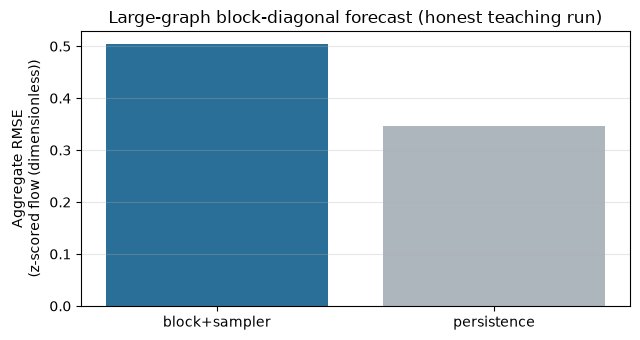


Scale / inverse probe summary
mode                  N   median_ms    rss_mb     rel_err
dense               128        5.87     456.1      0.0000
block_diagonal      128        0.07     456.1      0.0433

Train wall times — block+sampler (N=883): 1.78s; dense synthetic_path_n64: 0.28s
Jacobi caveat: block inverse rel-err on probe was 0.0433 (dense recovery 1.17e-07).


In [7]:
block_eval = block_model.evaluate(split.test, horizons=HORIZONS)
persist_rmses = multi_origin_rmse(persistence_predict, split.test, HORIZONS)
persist_agg = float(np.mean(list(persist_rmses.values())))
beats_persist = block_eval.aggregate_rmse < persist_agg

print(f"Units: MAE/RMSE in {FEATURE_UNIT}")
print(
    f"block+sampler  agg_mae={block_eval.aggregate_mae:.4f}  "
    f"agg_rmse={block_eval.aggregate_rmse:.4f}"
)
print(
    f"persistence    agg_rmse={persist_agg:.4f}  "
    f"(mean over horizons {HORIZONS})"
)
print(
    "Forecast quality vs persistence: "
    + (
        "model aggregate RMSE is lower"
        if beats_persist
        else "persistence wins (expected for this short teaching train)"
    )
)
for metric in block_eval.horizons:
    gap = metric.rmse - persist_rmses[metric.horizon]
    print(
        f"  h={metric.horizon}  mae={metric.mae:.4f}  rmse={metric.rmse:.4f}  "
        f"persist_rmse={persist_rmses[metric.horizon]:.4f}  "
        f"Δrmse={gap:+.4f}"
    )

labels = ["block+sampler", "persistence"]
vals = [block_eval.aggregate_rmse, persist_agg]
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.bar(labels, vals, color=["#2a6f97", "#adb5bd"])
ax.set_ylabel(f"Aggregate RMSE\n({FEATURE_UNIT})")
ax.set_title("Large-graph block-diagonal forecast (honest teaching run)")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

print("\nScale / inverse probe summary")
print(
    f"{'mode':16s}  {'N':>5s}  {'median_ms':>10s}  {'rss_mb':>8s}  "
    f"{'rel_err':>10s}"
)
for row in timing_rows:
    print(
        f"{row['mode']:16s}  {row['N']:5d}  {row['median_ms']:10.2f}  "
        f"{row['rss_mb']:8.1f}  {row['rel_err_to_z']:10.4f}"
    )
print(
    f"\nTrain wall times — block+sampler (N={sequence.num_nodes}): "
    f"{block_train_s:.2f}s; dense {DENSE_COMPARATOR_SOURCE}: "
    f"{dense_small_s:.2f}s"
)
print(
    f"Jacobi caveat: block inverse rel-err on probe was {rel_err:.4f} "
    f"(dense recovery {dense_rec_err:.2e})."
)


## Interpretation

- **Forward is shared.** Dense and `block_diagonal` use the same sparse advance;
  sparsity mainly changes `inverse_advance` and what you can afford at scale.
- **Approximate inverse.** One Jacobi step is **not** the exact whole-network
  inverse. Keep `backward=0` unless you accept that bias (Azencot-style
  bidirectional training needs the caveat).
- **Sampler ≠ smaller model at test time.** Training losses see subgraphs;
  evaluation still rolls out on the full sensor graph.
- **Teaching forecast vs persistence.** On the default PEMS07 window (short
  $T$, modest epochs, `backward=0`), persistence typically wins aggregate and
  per-horizon RMSE. The notebook’s goal is tractable large $N$ training and
  inverse timing — not a traffic SOTA claim. Longer data, richer losses, or
  denser schedules may change the gap; they are out of scope here.
- **Dense comparator is synthetic.** The `synthetic_path_n≤64` dense fit only
  shows that a small dense operator is cheap; it is not dense-on-PEMS07.
- **When dense is fine.** Tiny $N$ (IEEE 118, small synthetics): prefer
  `koopman_sparsity="dense"` for exact inverse and simpler mental model.


## Takeaways

- Pair `koopman_sparsity="block_diagonal"` with `NeighborWindowSampler` when
  $N$ makes dense $N\cdot d$ operators or full-graph windows expensive.
- Measure mid-size inverse timings and the dense $Nd\times Nd$ byte budget —
  never allocate the full teaching-graph effective matrix “just to compare.”
  Process RSS should stay on the order of hundreds of MB on a laptop demo, not
  $10^5$ MB.
- State the Jacobi approximate-inverse caveat whenever backward consistency is
  on the table.
- Do not read a short PEMS07 teaching run as a forecast win: persistence often
  beats `block+sampler` RMSE here; treat the bar chart as an honest baseline
  check, not a leaderboard result.
- Dense wall-time comparisons in this notebook use `synthetic_path_n≤64`, not
  dense PEMS07.
- PEMS07 is the largest PEMS0X teaching graph in this repo; fetch the cache
  rather than bundling Caltrans/community archives.


## Further reading

- API: `GraphKoopmanModel(..., koopman="graph", koopman_sparsity="block_diagonal")`,
  `koopman_graph.data.NeighborWindowSampler`,
  `GraphKoopmanOperator.inverse_advance`
- Architecture: Sphinx `architecture` — sparsity matrix (dense vs block_diagonal)
- Dataset card: Sphinx `data` — PEMS07
- Related notebooks: [`10_advanced_training.ipynb`](10_advanced_training.ipynb),
  [`18_networked_koopman_dynamic_topology.ipynb`](18_networked_koopman_dynamic_topology.ipynb),
  [`28_adaptive_topology_learning.ipynb`](28_adaptive_topology_learning.ipynb)
- Citations (`paper.bib`): `Mukherjee2022`, `Azarbahram2025`, `Azencot2020`
